In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/AlexisG81/prestige/refs/heads/main/Files/Prestige_completo.csv',sep=';')

In [3]:
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.describe())


(102, 8)
         professionals  education  income  women  prestige  census  type  \
0   gov.administrators      13.11   12351  11.16      68.8    1113  prof   
1     general.managers      12.26   25879   4.02      69.1    1130  prof   
2          accountants      12.77    9271  15.70      63.4    1171  prof   
3  purchasing.officers      11.42    8865   9.11      56.8    1175  prof   
4             chemists      14.62    8403  11.68      73.5    2111  prof   

   type_num  
0         1  
1         1  
2         1  
3         1  
4         1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   professionals  102 non-null    object 
 1   education      102 non-null    float64
 2   income         102 non-null    int64  
 3   women          102 non-null    float64
 4   prestige       102 non-null    float64
 5   census         102 non-null    in

In [4]:
variables_numericas = df.select_dtypes(include=['int64', 'float64'])
matriz_correlacion = variables_numericas.corr()

print(matriz_correlacion.round(3))
print(matriz_correlacion['prestige'].sort_values(ascending=False).round(3))


           education  income  women  prestige  census  type_num
education      1.000   0.578  0.062     0.850  -0.823    -0.382
income         0.578   1.000 -0.441     0.715  -0.361    -0.368
women          0.062  -0.441  1.000    -0.118  -0.227     0.251
prestige       0.850   0.715 -0.118     1.000  -0.635    -0.465
census        -0.823  -0.361 -0.227    -0.635   1.000     0.288
type_num      -0.382  -0.368  0.251    -0.465   0.288     1.000
prestige     1.000
education    0.850
income       0.715
women       -0.118
type_num    -0.465
census      -0.635
Name: prestige, dtype: float64


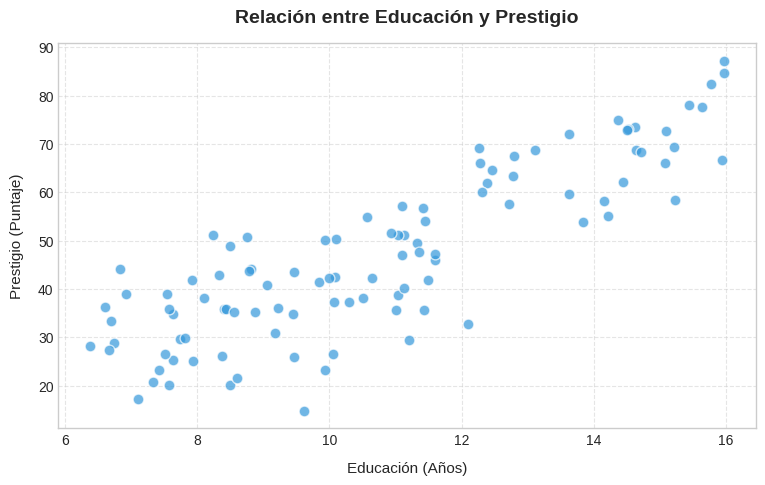

In [5]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(9, 5))

plt.scatter(df['education'], df['prestige'], color='#3498db', s=60, alpha=0.7, edgecolors='white')
plt.title('Relación entre Educación y Prestigio', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Educación (Años)', fontsize=11, labelpad=10)
plt.ylabel('Prestigio (Puntaje)', fontsize=11, labelpad=10)


plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


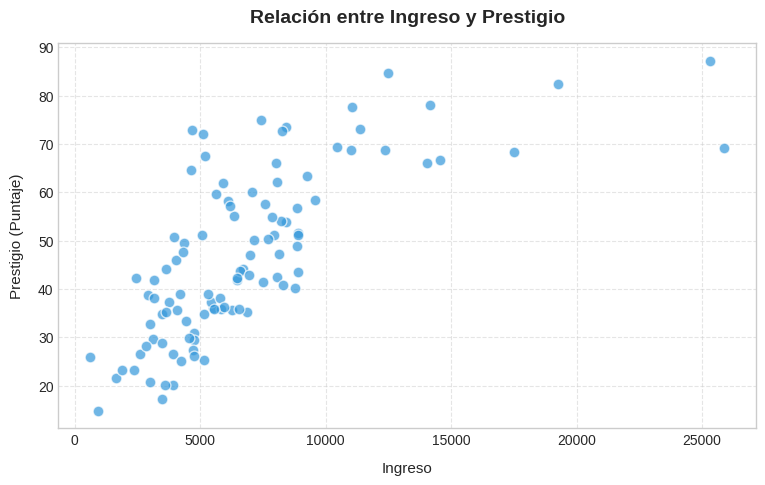

In [6]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(9, 5))


plt.scatter(df['income'], df['prestige'], color='#3498db', s=60, alpha=0.7, edgecolors='white')
plt.title('Relación entre Ingreso y Prestigio', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ingreso', fontsize=11, labelpad=10)
plt.ylabel('Prestigio (Puntaje)', fontsize=11, labelpad=10)


plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

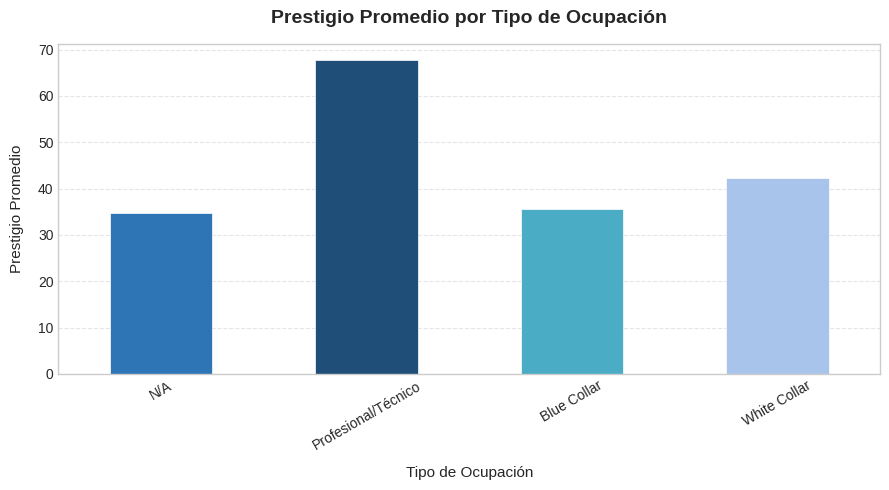

In [7]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(9, 5))


df.groupby('type_num')['prestige'].mean().plot(
    kind='bar',
    color=['#2E75B6', '#1F4E79', '#4BACC6', '#A9C4EB'],
    edgecolor='white',
    linewidth=0.5
)


plt.title('Prestigio Promedio por Tipo de Ocupación', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tipo de Ocupación', fontsize=11, labelpad=10)
plt.ylabel('Prestigio Promedio', fontsize=11, labelpad=10)
plt.xticks(ticks=[0, 1, 2, 3], labels=['N/A', 'Profesional/Técnico', 'Blue Collar', 'White Collar'], rotation=30, fontsize=10)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.grid(False, axis='x')

plt.tight_layout()
plt.show()


In [8]:
columnas_cluster = ['education', 'income', 'women', 'prestige', 'type_num']
X = df[columnas_cluster].copy()

escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)


In [9]:
modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)

print(df.groupby('Cluster_4')[columnas_cluster].mean().round(2))


           education    income  women  prestige  type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00


In [10]:
modelo_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)

print(df.groupby('Cluster_5')[columnas_cluster].mean().round(2))


           education    income  women  prestige  type_num
Cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00
